In [1]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy.optimize import minimize, curve_fit
from fredapi import Fred

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted")
pd.set_option("display.float_format", "{:.4f}".format)

In [ ]:
FRED_API_KEY = os.environ["FRED_API_KEY"]
fred = Fred(api_key=FRED_API_KEY)

TENOR_MAP = {
    "1mo":  "DGS1MO",
    "3mo":  "DGS3MO",
    "6mo":  "DGS6MO",
    "1yr":  "DGS1",
    "2yr":  "DGS2",
    "3yr":  "DGS3",
    "5yr":  "DGS5",
    "7yr":  "DGS7",
    "10yr": "DGS10",
    "20yr": "DGS20",
    "30yr": "DGS30",
}

# Numeric maturity in years — used as tau in NS formula
TENOR_YEARS = {
    "1mo": 1/12, "3mo": 3/12, "6mo": 6/12,
    "1yr": 1, "2yr": 2, "3yr": 3, "5yr": 5,
    "7yr": 7, "10yr": 10, "20yr": 20, "30yr": 30,
}

In [3]:
os.makedirs("data", exist_ok=True)

raw_frames = {}
for label, series_id in TENOR_MAP.items():
    s = fred.get_series(series_id, observation_start="2000-01-01")
    s.name = label
    raw_frames[label] = s
    print(f"  fetched {label}: {len(s)} obs")

yields_raw = pd.DataFrame(raw_frames)
yields_raw.index.name = "date"
yields_raw.to_csv("data/yields_raw.csv")
print(f"\nRaw shape: {yields_raw.shape}")
yields_raw.tail()

  fetched 1mo: 6440 obs
  fetched 3mo: 6851 obs
  fetched 6mo: 6851 obs
  fetched 1yr: 6851 obs
  fetched 2yr: 6851 obs
  fetched 3yr: 6851 obs
  fetched 5yr: 6851 obs
  fetched 7yr: 6851 obs
  fetched 10yr: 6851 obs
  fetched 20yr: 6851 obs
  fetched 30yr: 6851 obs

Raw shape: (6851, 11)


,1mo,3mo,6mo,1yr,2yr,3yr,5yr,7yr,10yr,20yr,30yr
date,,,,,,,,,,,
2026-03-31,3.7400,3.7000,3.7200,3.6800,3.7900,3.8100,3.9200,4.1100,4.3000,4.8800,4.8800
2026-04-01,3.7400,3.7000,3.7200,3.6800,3.8100,3.8400,3.9700,4.1500,4.3300,4.9100,4.9100
2026-04-02,3.7200,3.7000,3.7200,3.6800,3.7900,3.8200,3.9400,4.1200,4.3100,4.8800,4.8800
2026-04-03,3.7100,3.7100,3.7300,3.7200,3.8400,3.8800,3.9900,4.1700,4.3500,4.9100,4.9100
2026-04-06,3.7200,3.7200,3.7400,3.7200,3.8400,3.8800,3.9800,4.1600,4.3400,4.8900,4.8900


In [ ]:
# yields_raw.to_csv("data/yields_raw.csv")

In [6]:
yields = yields_raw.copy()

# FRED uses '.' for missing — already NaN after fredapi parse
# Forward fill up to 5 business days (handles holidays, short gaps)
yields = yields.ffill(limit=5)

# Drop any remaining rows missing 3+ tenors
thresh = len(TENOR_MAP) - 2
yields = yields.dropna(thresh=thresh)

print(f"Clean shape : {yields.shape}")
print(f"Date range  : {yields.index.min()} → {yields.index.max()}")
print(f"Missing vals: {yields.isna().sum().sum()} remaining")

yields.to_csv("data/yields_clean.csv")
yields.head()

Clean shape : (6851, 11)
Date range  : 2000-01-03 00:00:00 → 2026-04-06 00:00:00
Missing vals: 411 remaining


,1mo,3mo,6mo,1yr,2yr,3yr,5yr,7yr,10yr,20yr,30yr
date,,,,,,,,,,,
2000-01-03,NaN,5.4800,5.8100,6.0900,6.3800,6.4200,6.5000,6.6500,6.5800,6.9400,6.6100
2000-01-04,NaN,5.4300,5.7500,6.0000,6.3000,6.3400,6.4000,6.5600,6.4900,6.8400,6.5300
2000-01-05,NaN,5.4400,5.7400,6.0500,6.3800,6.4300,6.5100,6.6800,6.6200,6.9500,6.6400
2000-01-06,NaN,5.4100,5.6900,6.0300,6.3500,6.3900,6.4600,6.6300,6.5700,6.8600,6.5800
2000-01-07,NaN,5.3800,5.6600,6.0000,6.3100,6.3500,6.4200,6.5800,6.5200,6.8200,6.5500


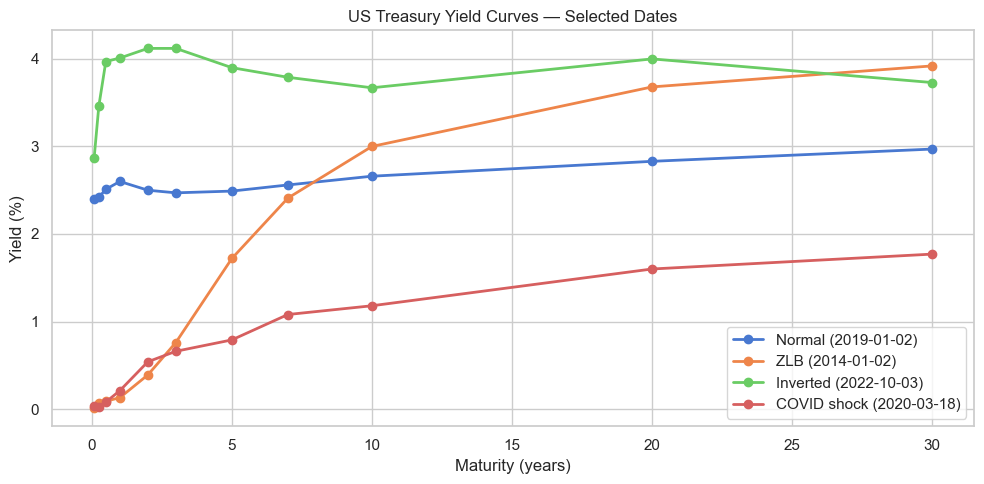

In [7]:
HIGHLIGHT_DATES = {
    "Normal (2019-01-02)":    "2019-01-02",
    "ZLB (2014-01-02)":       "2014-01-02",
    "Inverted (2022-10-03)":  "2022-10-03",
    "COVID shock (2020-03-18)":"2020-03-18",
}

taus = list(TENOR_YEARS.values())
tenor_labels = list(TENOR_YEARS.keys())

fig, ax = plt.subplots(figsize=(10, 5))
for label, date in HIGHLIGHT_DATES.items():
    row = yields.loc[yields.index >= date].iloc[0]
    ax.plot(taus, row.values, marker="o", label=label, linewidth=2)

ax.set_xlabel("Maturity (years)")
ax.set_ylabel("Yield (%)")
ax.set_title("US Treasury Yield Curves — Selected Dates")
ax.legend()
plt.tight_layout()
plt.savefig("data/fig_raw_curves.png", dpi=150)
plt.show()

In [8]:
def ns_yield(tau, beta0, beta1, beta2, lam):
    """Nelson-Siegel yield for a single maturity tau (in years)."""
    tau = np.maximum(tau, 1e-6)          # guard against tau=0
    factor = (1 - np.exp(-tau / lam)) / (tau / lam)
    y = beta0 + beta1 * factor + beta2 * (factor - np.exp(-tau / lam))
    return y

def ns_rmse(params, taus, market_yields):
    """Residual for optimizer — ignores NaN tenors."""
    b0, b1, b2, lam = params
    lam = max(lam, 0.01)                 # prevent numerical issues
    fitted = ns_yield(np.array(taus), b0, b1, b2, lam)
    mask = ~np.isnan(market_yields)
    residuals = fitted[mask] - market_yields[mask]
    return np.sqrt(np.mean(residuals**2))

def fit_ns(market_yields_series, fix_lambda=None):
    """
    Fit NS model to one date's yield curve.
    
    Parameters
    ----------
    market_yields_series : pd.Series  (index = tenor labels)
    fix_lambda           : float or None — if float, lambda is fixed

    Returns
    -------
    dict with beta0, beta1, beta2, lam, rmse, success
    """
    taus   = [TENOR_YEARS[t] for t in market_yields_series.index]
    yields = market_yields_series.values.astype(float)

    # Initial guess: level=current 10yr, slope=spread, curvature=0
    y10  = market_yields_series.get("10yr", 3.0)
    y3mo = market_yields_series.get("3mo",  2.0)
    b0_init = float(y10) if not np.isnan(y10) else 3.0
    b1_init = float(y3mo - y10) if not np.isnan(y3mo) else -1.0

    if fix_lambda is not None:
        # 3-param optimization, lambda fixed
        def obj(p): return ns_rmse([p[0], p[1], p[2], fix_lambda], taus, yields)
        x0 = [b0_init, b1_init, 0.5]
        bounds = [(0, 15), (-10, 10), (-10, 10)]
        res = minimize(obj, x0, method="L-BFGS-B", bounds=bounds)
        b0, b1, b2 = res.x
        lam = fix_lambda
    else:
        # 4-param optimization
        def obj(p): return ns_rmse(p, taus, yields)
        x0 = [b0_init, b1_init, 0.5, 0.0609]
        bounds = [(0, 15), (-10, 10), (-10, 10), (0.01, 5.0)]
        res = minimize(obj, x0, method="L-BFGS-B", bounds=bounds)
        b0, b1, b2, lam = res.x

    rmse = ns_rmse([b0, b1, b2, lam], taus, yields)
    return {"beta0": b0, "beta1": b1, "beta2": b2,
            "lam": lam, "rmse": rmse, "success": res.success}

In [13]:
def fit_ns_robust(market_yields_series, fix_lambda=0.0609):
    taus   = [TENOR_YEARS[t] for t in market_yields_series.index]
    mkt    = market_yields_series.values.astype(float)

    starting_points = [
        [3.0, -1.0,  0.5],
        [5.0, -2.0,  1.0],
        [2.0,  0.5, -0.5],
        [4.0, -3.0,  2.0],
        [4.0, -1.0, -1.0],   # negative beta2 — key for humped/inverted curves
        [6.0,  0.0,  0.0],
        [4.5, -0.5, -2.0],
    ]

    best_rmse, best_params = np.inf, None

    for x0 in starting_points:
        def obj(p): return ns_rmse([p[0], p[1], p[2], fix_lambda], taus, mkt)
        res = minimize(obj, x0, method="L-BFGS-B",
                       bounds=[(0,15), (-10,10), (-10,10)])
        if res.fun < best_rmse:
            best_rmse   = res.fun
            best_params = res.x

    b0, b1, b2 = best_params
    return {"beta0": b0, "beta1": b1, "beta2": b2,
            "lam": fix_lambda, "rmse": best_rmse}

In [18]:
def fit_ns_free(market_yields_series):
    taus = [TENOR_YEARS[t] for t in market_yields_series.index]
    mkt  = market_yields_series.values.astype(float)

    starting_points = [
        [3.0, -1.0,  0.5, 0.0609],
        [5.0, -2.0,  1.0, 0.5],
        [4.0, -1.0, -1.0, 1.5],
        [4.0,  0.5,  0.5, 3.0],
        [4.5, -0.5, -2.0, 0.1],
    ]

    best_rmse, best_params = np.inf, None

    for x0 in starting_points:
        def obj(p): return ns_rmse(p, taus, mkt)
        res = minimize(obj, x0, method="L-BFGS-B",
                       bounds=[(0,15),(-10,10),(-10,10),(0.01,5.0)])
        if res.fun < best_rmse:
            best_rmse   = res.fun
            best_params = res.x

    b0, b1, b2, lam = best_params
    return {"beta0": b0, "beta1": b1, "beta2": b2,
            "lam": lam, "rmse": best_rmse}

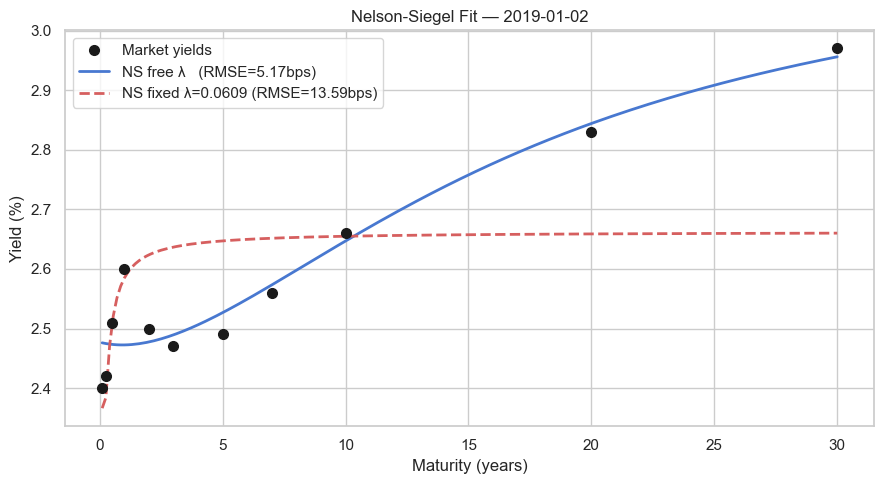


Free lambda fit:
  beta0    = 3.2168
  beta1    = -0.7399
  beta2    = -0.8421
  lam      = 5.0000
  rmse     = 0.0517
  success  = 1.0000

Fixed lambda fit:
  beta0    = 2.6626
  beta1    = 0.4390
  beta2    = -1.7207
  lam      = 0.0609
  rmse     = 0.1359
  success  = 1.0000


In [20]:
date = "2019-01-02"
row  = yields.loc[yields.index >= date].iloc[0]

# Free lambda fit
res_free = fit_ns(row, fix_lambda=None)
# Fixed lambda fit (Diebold-Li convention)
res_fixed = fit_ns(row, fix_lambda=0.0609)

tau_fine = np.linspace(0.1, 30, 200)
fitted_free  = ns_yield(tau_fine, **{k: res_free[k]  for k in ["beta0","beta1","beta2","lam"]})
fitted_fixed = ns_yield(tau_fine, **{k: res_fixed[k] for k in ["beta0","beta1","beta2","lam"]})

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(taus, row.values, "ko", markersize=7, label="Market yields", zorder=5)
ax.plot(tau_fine, fitted_free,  "b-", linewidth=2, label=f"NS free λ   (RMSE={res_free['rmse']*100:.2f}bps)")
ax.plot(tau_fine, fitted_fixed, "r--", linewidth=2, label=f"NS fixed λ=0.0609 (RMSE={res_fixed['rmse']*100:.2f}bps)")
ax.set_xlabel("Maturity (years)")
ax.set_ylabel("Yield (%)")
ax.set_title(f"Nelson-Siegel Fit — {date}")
ax.legend()
plt.tight_layout()
plt.savefig("data/fig_ns_single_fit.png", dpi=150)
plt.show()

print("\nFree lambda fit:")
for k, v in res_free.items():
    print(f"  {k:8s} = {v:.4f}")
print(f"\nFixed lambda fit:")
for k, v in res_fixed.items():
    print(f"  {k:8s} = {v:.4f}")

In [21]:
# records = []
records = []
for date, row in yields.iterrows():
    res = fit_ns_free(row)
    records.append({"date": date, **res})

ns_params = pd.DataFrame(records).set_index("date")
ns_params.to_csv("data/ns_params.csv")
print(f"Fitted {len(ns_params)} dates")
print(f"Median RMSE : {ns_params['rmse'].median()*100:.2f} bps")
print(f"% days < 10bps RMSE: {(ns_params['rmse'] < 0.10).mean()*100:.1f}%")

Fitted 6851 dates
Median RMSE : 4.88 bps
% days < 10bps RMSE: 91.6%


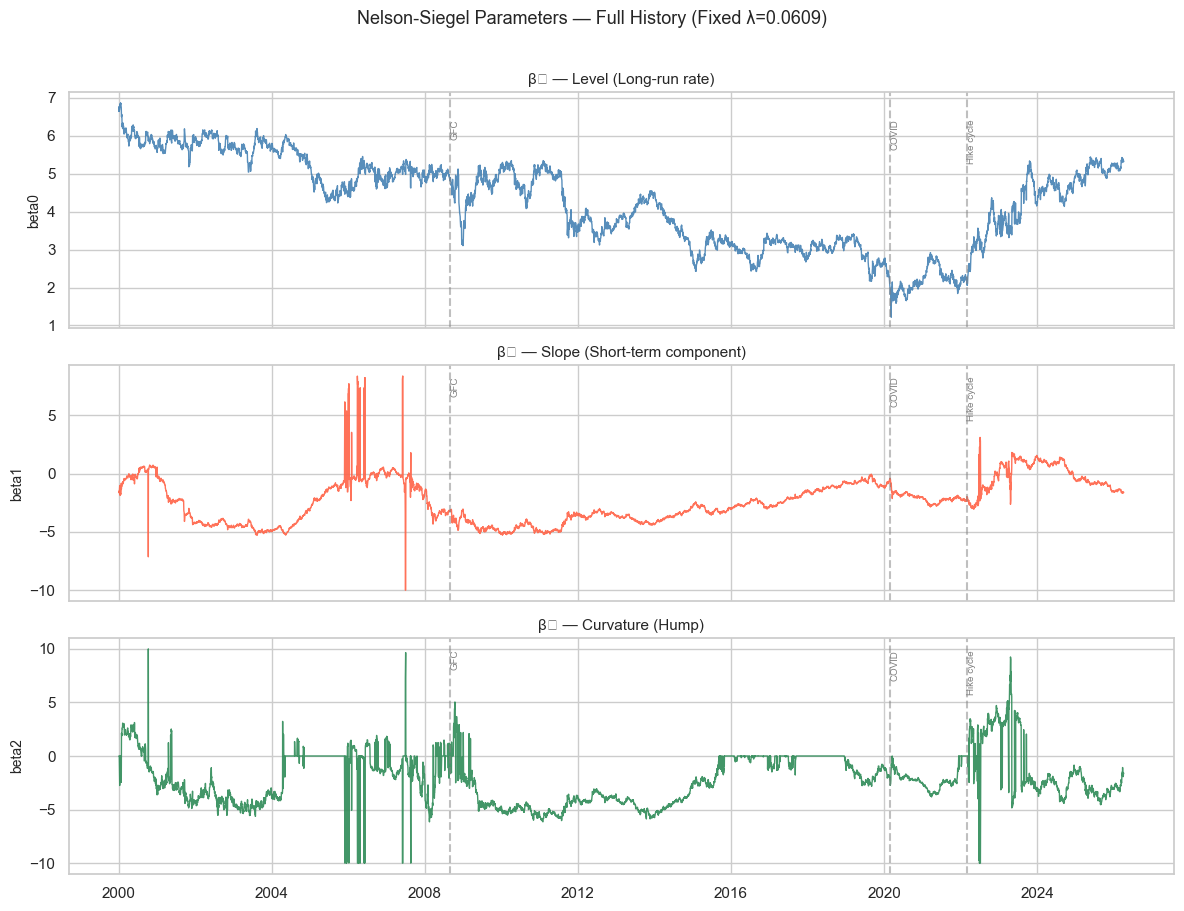

In [23]:
ig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)

param_meta = [
    ("beta0", "β₀ — Level (Long-run rate)", "steelblue"),
    ("beta1", "β₁ — Slope (Short-term component)", "tomato"),
    ("beta2", "β₂ — Curvature (Hump)", "seagreen"),
]

# Annotate major rate regimes
regimes = [
    ("2008-09-01", "GFC"),
    ("2020-03-01", "COVID"),
    ("2022-03-01", "Hike cycle"),
]

for ax, (col, title, color) in zip(axes, param_meta):
    ax.plot(ns_params.index, ns_params[col], color=color, linewidth=1, alpha=0.9)
    ax.set_ylabel(col, fontsize=10)
    ax.set_title(title, fontsize=11)
    for reg_date, reg_label in regimes:
        ax.axvline(pd.Timestamp(reg_date), color="gray", linestyle="--", alpha=0.5)
        ax.text(pd.Timestamp(reg_date), ax.get_ylim()[1]*0.9, reg_label,
                fontsize=7, color="gray", rotation=90, va="top")

axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
plt.suptitle("Nelson-Siegel Parameters — Full History (Fixed λ=0.0609)", y=1.01, fontsize=13)
plt.tight_layout()
plt.savefig("data/fig_ns_params_history.png", dpi=150)
plt.show()

In [24]:
#Per Diebold-Li:
#   beta0  ≈ 30yr yield  (level)
#   -beta1 ≈ 30yr - 3mo  (slope)
#   beta2  ≈ 2×2yr - 3mo - 30yr  (curvature proxy)

level_proxy     = yields["30yr"]
slope_proxy     = yields["30yr"] - yields["3mo"]
curve_proxy     = 2*yields["2yr"] - yields["3mo"] - yields["30yr"]

corr_level = ns_params["beta0"].corr(level_proxy)
corr_slope = (-ns_params["beta1"]).corr(slope_proxy)
corr_curve = ns_params["beta2"].corr(curve_proxy)

print("Factor proxy correlations (should be high):")
print(f"  β₀  vs 30yr yield       : {corr_level:.3f}")
print(f"  -β₁ vs (30yr - 3mo)     : {corr_slope:.3f}")
print(f"  β₂  vs curvature proxy  : {corr_curve:.3f}")

Factor proxy correlations (should be high):
  β₀  vs 30yr yield       : 0.981
  -β₁ vs (30yr - 3mo)     : 0.947
  β₂  vs curvature proxy  : 0.758


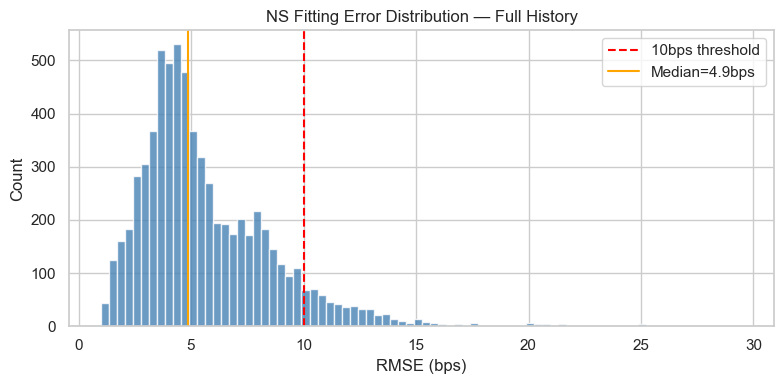


Dates with RMSE > 10bps: 577
Sample high-error dates: [Timestamp('2000-05-03 00:00:00'), Timestamp('2000-05-04 00:00:00'), Timestamp('2000-05-05 00:00:00'), Timestamp('2000-05-08 00:00:00'), Timestamp('2000-05-09 00:00:00')]


In [25]:
fig, ax = plt.subplots(figsize=(8, 4))
rmse_bps = ns_params["rmse"] * 100
ax.hist(rmse_bps, bins=80, color="steelblue", edgecolor="white", alpha=0.8)
ax.axvline(10, color="red", linestyle="--", label="10bps threshold")
ax.axvline(rmse_bps.median(), color="orange", linestyle="-", label=f"Median={rmse_bps.median():.1f}bps")
ax.set_xlabel("RMSE (bps)")
ax.set_ylabel("Count")
ax.set_title("NS Fitting Error Distribution — Full History")
ax.legend()
plt.tight_layout()
plt.savefig("data/fig_rmse_dist.png", dpi=150)
plt.show()

high_error_dates = ns_params[ns_params["rmse"] > 0.10].index
print(f"\nDates with RMSE > 10bps: {len(high_error_dates)}")
print("Sample high-error dates:", high_error_dates[:5].tolist())


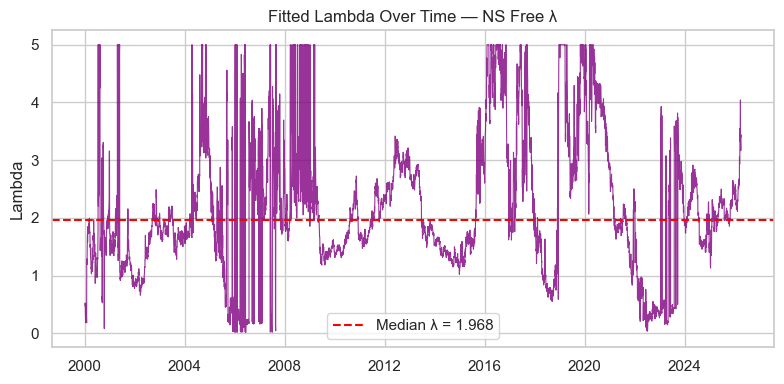

Median lambda : 1.9675
Mean lambda   : 2.1919
Std lambda    : 1.1937

NS  median RMSE on sample : 4.93 bps
SV  median RMSE on sample : 3.67 bps


In [26]:
# ── CELL 12: Lambda Distribution + Svensson Model ────────────

# --- Part A: Lambda distribution plot ---
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(ns_params.index, ns_params["lam"], color="purple", linewidth=0.8, alpha=0.8)
ax.set_ylabel("Lambda")
ax.set_title("Fitted Lambda Over Time — NS Free λ")
ax.axhline(ns_params["lam"].median(), color="red", linestyle="--",
           label=f"Median λ = {ns_params['lam'].median():.3f}")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.legend()
plt.tight_layout()
plt.savefig("data/fig_lambda_history.png", dpi=150)
plt.show()

print(f"Median lambda : {ns_params['lam'].median():.4f}")
print(f"Mean lambda   : {ns_params['lam'].mean():.4f}")
print(f"Std lambda    : {ns_params['lam'].std():.4f}")

# --- Part B: Svensson model functions ---
def svensson_yield(tau, b0, b1, b2, b3, lam1, lam2):
    """Svensson (1994) extended NS with second hump term."""
    tau = np.maximum(tau, 1e-6)
    f1 = (1 - np.exp(-tau/lam1)) / (tau/lam1)
    f2 = f1 - np.exp(-tau/lam1)
    f3 = (1 - np.exp(-tau/lam2)) / (tau/lam2) - np.exp(-tau/lam2)
    return b0 + b1*f1 + b2*f2 + b3*f3

def fit_svensson(market_yields_series):
    """Fit Svensson model — 6 free parameters."""
    taus = [TENOR_YEARS[t] for t in market_yields_series.index]
    mkt  = market_yields_series.values.astype(float)
    mask = ~np.isnan(mkt)

    def obj(p):
        fitted = svensson_yield(np.array(taus), *p)
        return np.sqrt(np.mean((fitted[mask] - mkt[mask])**2))

    starting_points = [
        [4.0, -1.0,  0.5,  0.5, 0.5, 3.0],
        [5.0, -2.0,  1.0,  1.0, 1.5, 5.0],
        [3.0, -0.5, -1.0, -0.5, 3.0, 0.5],
    ]
    best_rmse, best_params = np.inf, None
    bounds = [(0,15),(-10,10),(-10,10),(-10,10),(0.01,5),(0.01,10)]

    for x0 in starting_points:
        res = minimize(obj, x0, method="L-BFGS-B", bounds=bounds)
        if res.fun < best_rmse:
            best_rmse   = res.fun
            best_params = res.x

    b0, b1, b2, b3, lam1, lam2 = best_params
    return {"b0": b0, "b1": b1, "b2": b2, "b3": b3,
            "lam1": lam1, "lam2": lam2, "rmse": best_rmse}

# --- Part C: Fit Svensson on 10% sample ---
sample_dates = yields.index[::10]
sv_records = []
for date in sample_dates:
    row = yields.loc[date]
    res = fit_svensson(row)
    sv_records.append({"date": date, **res})

sv_params = pd.DataFrame(sv_records).set_index("date")
sv_params.to_csv("data/svensson_params.csv")

ns_sample_rmse = ns_params.loc[ns_params.index.isin(sample_dates), "rmse"] * 100
sv_sample_rmse = sv_params["rmse"] * 100

print(f"\nNS  median RMSE on sample : {ns_sample_rmse.median():.2f} bps")
print(f"SV  median RMSE on sample : {sv_sample_rmse.median():.2f} bps")

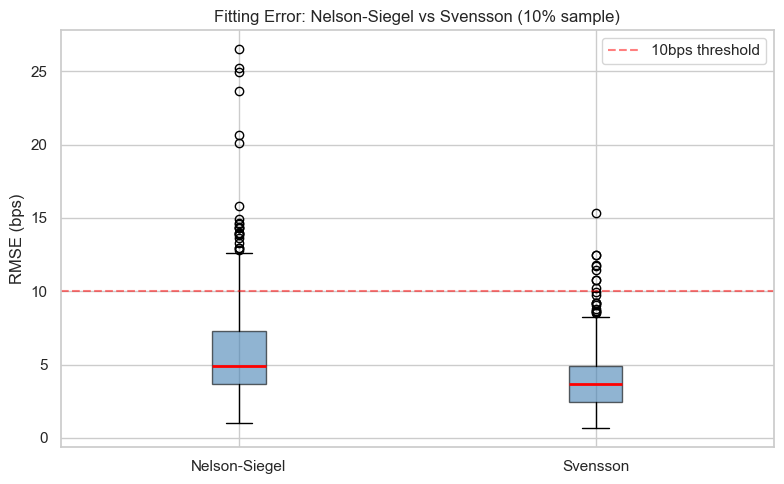

In [28]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.boxplot(
    [ns_sample_rmse.dropna(), sv_sample_rmse.dropna()],
    labels=["Nelson-Siegel", "Svensson"],
    patch_artist=True,
    boxprops=dict(facecolor="steelblue", alpha=0.6),
    medianprops=dict(color="red", linewidth=2),
)
ax.set_ylabel("RMSE (bps)")
ax.set_title("Fitting Error: Nelson-Siegel vs Svensson (10% sample)")
ax.axhline(10, color="red", linestyle="--", alpha=0.5, label="10bps threshold")
ax.legend()
plt.tight_layout()
plt.savefig("data/fig_ns_vs_svensson.png", dpi=150)
plt.show()

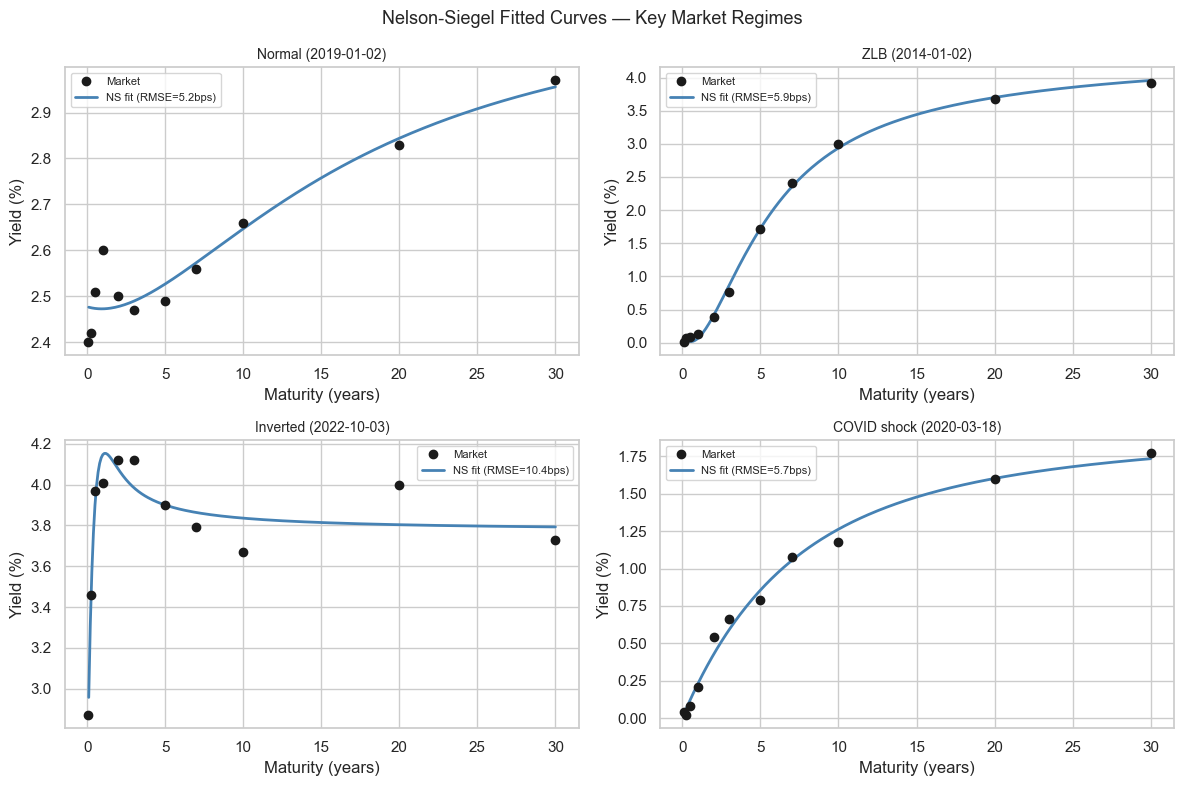

In [29]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

showcase_dates = list(HIGHLIGHT_DATES.items())
tau_fine = np.linspace(0.1, 30, 300)

for ax, (label, date) in zip(axes, showcase_dates):
    row = yields.loc[yields.index >= date].iloc[0]
    params = ns_params.loc[ns_params.index >= date].iloc[0]

    fitted = ns_yield(tau_fine,
                      params["beta0"], params["beta1"],
                      params["beta2"], params["lam"])

    ax.plot(taus, row.values, "ko", markersize=6, label="Market", zorder=5)
    ax.plot(tau_fine, fitted, "steelblue", linewidth=2,
            label=f"NS fit (RMSE={params['rmse']*100:.1f}bps)")
    ax.set_title(label, fontsize=10)
    ax.set_xlabel("Maturity (years)")
    ax.set_ylabel("Yield (%)")
    ax.legend(fontsize=8)

plt.suptitle("Nelson-Siegel Fitted Curves — Key Market Regimes", fontsize=13)
plt.tight_layout()
plt.savefig("data/fig_ns_showcase.png", dpi=150)
plt.show()

In [ ]:
print("=" * 55)
print("VALIDATION CHECKLIST — NOTEBOOK 01")
print("=" * 55)

pct_under_10bps = (ns_params["rmse"] < 0.10).mean() * 100
print(f"\n[{'PASS' if pct_under_10bps > 85 else 'FAIL'}] "
      f"NS RMSE < 10bps on >85% of days : {pct_under_10bps:.1f}%")

corr_thresh = 0.85
print(f"\n[{'PASS' if corr_level > corr_thresh else 'FAIL'}] "
      f"β₀ correlation with 30yr yield  : {corr_level:.3f}")
print(f"[{'PASS' if corr_slope > corr_thresh else 'FAIL'}] "
      f"-β₁ correlation with slope proxy: {corr_slope:.3f}")
print(f"[{'PASS' if corr_curve > 0.7 else 'FAIL'}] "
      f"β₂ correlation with curve proxy : {corr_curve:.3f}")

sv_beats_ns = (sv_sample_rmse.median() < ns_sample_rmse.median())
print(f"\n[{'PASS' if sv_beats_ns else 'NOTE'}] "
      f"Svensson RMSE < NS RMSE         : {sv_beats_ns}")

print(f"\nOutputs saved to data/:")
print("  yields_raw.csv, yields_clean.csv")
print("  ns_params.csv, svensson_params.csv")
print("  fig_*.png (6 plots)")
print("\nNotebook 01 complete. Feed ns_params.csv into notebook 02.")